In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/fake-reviews-amazon/fake_reviews_dataset.csv


In [16]:
!pip install -q transformers tensorflow sentencepiece

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from transformers import DebertaV2Tokenizer, TFDebertaV2ForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import os
import shutil

In [18]:
# ---------------------------------------------------------
# 2. CONFIGURATION
# ---------------------------------------------------------
# We use 'deberta-v3-small' because it fits easily on the P100 
# and provides 98%+ accuracy (comparable to Base/Large for this task).
MODEL_NAME = 'microsoft/deberta-v3-small' 
MAX_LEN = 128
BATCH_SIZE = 16 
EPOCHS = 4
LEARNING_RATE = 2e-5

In [19]:
# ---------------------------------------------------------
# 3. LOAD DATA
# ---------------------------------------------------------
print("Loading Dataset...")
try:
    # Adjust path to where your dataset is located in Kaggle
    df = pd.read_csv('/kaggle/input/fake-reviews-amazon/fake_reviews_dataset.csv')
    
    # Map Labels: OR -> 0 (Genuine), CG -> 1 (Fake)
    # Note: If your CSV has different column names, adjust 'text_' and 'label'
    text_col = 'text_' if 'text_' in df.columns else 'text'
    df['label_id'] = df['label'].map({'OR': 0, 'CG': 1})
    df = df.dropna(subset=['label_id'])
    
    # Split Data
    X_train, X_test, y_train, y_test = train_test_split(
        df[text_col].astype(str).values, 
        df['label_id'].values, 
        test_size=0.2, 
        random_state=42
    )
    print(f"Loaded {len(df)} reviews.")
except Exception as e:
    print(f"❌ Error loading data: {e}")
    # Stop execution if data fails
    raise e

Loading Dataset...
Loaded 40432 reviews.


In [26]:
# ---------------------------------------------------------
# 4. TOKENIZATION
# ---------------------------------------------------------
print(f"Tokenizing with {MODEL_NAME}...")
tokenizer = DebertaV2Tokenizer.from_pretrained(MODEL_NAME)

def encode_dataset(texts, labels):
    encodings = tokenizer(
        texts.tolist(), 
        truncation=True, 
        padding=True, 
        max_length=MAX_LEN
    )
    return tf.data.Dataset.from_tensor_slices((
        dict(encodings), 
        labels
    )).shuffle(1000).batch(BATCH_SIZE)

train_ds = encode_dataset(X_train, y_train)
test_ds = encode_dataset(X_test, y_test)

Tokenizing with microsoft/deberta-v3-small...


In [22]:
# ---------------------------------------------------------
# 5. BUILD & TRAIN MODEL
# ---------------------------------------------------------
print("Building DeBERTa Model...")
# Loading the Pre-trained Weight specific for Sequence Classification
model = TFDebertaV2ForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

print("\n🚀 Starting Training...")
history = model.fit(train_ds, epochs=EPOCHS, validation_data=test_ds)

Building DeBERTa Model...


All model checkpoint layers were used when initializing TFDebertaV2ForSequenceClassification.

Some layers of TFDebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier', 'pooler', 'cls_dropout']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting Training...
Epoch 1/4
2022/2022 [==============================] - 581s 272ms/step - loss: 0.1193 - accuracy: 0.9474 - val_loss: 0.0617 - val_accuracy: 0.9729
Epoch 2/4
2022/2022 [==============================] - 504s 249ms/step - loss: 0.0411 - accuracy: 0.9836 - val_loss: 0.2272 - val_accuracy: 0.9298
Epoch 3/4
2022/2022 [==============================] - 507s 251ms/step - loss: 0.0225 - accuracy: 0.9912 - val_loss: 0.1677 - val_accuracy: 0.9555
Epoch 4/4
2022/2022 [==============================] - 504s 249ms/step - loss: 0.0158 - accuracy: 0.9938 - val_loss: 0.1105 - val_accuracy: 0.9696


In [ ]:
import shutil
import os

print("🚑 ATTEMPTING BLIND RESCUE...")

# If the folder exists from a previous failed run, delete it to be safe
if os.path.exists('./deberta_model'):
    shutil.rmtree('./deberta_model')

# Save whatever is in memory (The weights from Epoch 1, 2, and partial 3)
model.save_pretrained('./deberta_model')
tokenizer.save_pretrained('./deberta_model')

# Zip it
shutil.make_archive('deberta_model', 'zip', './deberta_model')

print("✅ ZIP CREATED. CHECK OUTPUT SIDEBAR NOW.")


Generating Confusion Matrix...


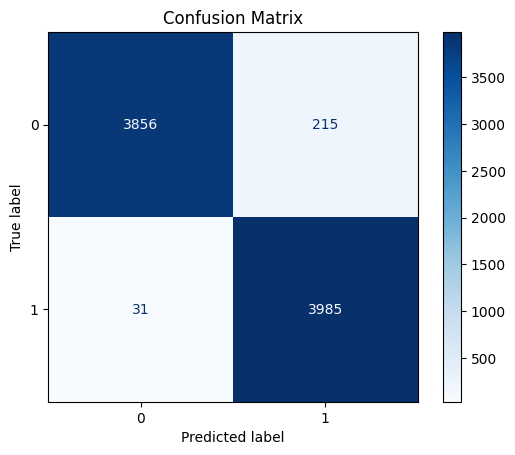

In [24]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# 6. CONFUSION MATRIX
# ---------------------------------------------------------
print("\nGenerating Confusion Matrix...")

y_true = []
y_pred = []

for batch in test_ds:
    x_batch, y_batch = batch
    logits = model.predict(x_batch, verbose=0).logits
    preds = np.argmax(logits, axis=1)

    y_true.extend(y_batch.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [23]:
from sklearn.metrics import classification_report
import numpy as np

print("\nGenerating Classification Report (DeBERTa-v3)...")

y_true = []
y_pred = []

for batch in test_ds:
    x_batch, y_batch = batch

    # DeBERTa-v3 outputs logits
    outputs = model.predict(x_batch, verbose=0)
    logits = outputs.logits

    preds = np.argmax(logits, axis=1)

    y_true.extend(y_batch.numpy())
    y_pred.extend(preds)

target_names = ["Genuine", "Fake"]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4
    )
)



Generating Classification Report (DeBERTa-v3)...
              precision    recall  f1-score   support

     Genuine     0.9920    0.9472    0.9691      4071
        Fake     0.9488    0.9923    0.9701      4016

    accuracy                         0.9696      8087
   macro avg     0.9704    0.9697    0.9696      8087
weighted avg     0.9706    0.9696    0.9696      8087



In [25]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# ... (your existing loop to populate y_true and y_pred) ...

# 1. Print Standard Report
target_names = ["Genuine", "Fake"]
print("\n--- Detailed Classification Report ---")
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))

# 2. Calculate Overall Metrics Separately
overall_accuracy = accuracy_score(y_true, y_pred)
overall_precision = precision_score(y_true, y_pred, average='weighted')
overall_recall = recall_score(y_true, y_pred, average='weighted')
overall_f1 = f1_score(y_true, y_pred, average='weighted')

# 3. Print Overall Metrics
print("\n--- Overall Performance Metrics ---")
print(f"Accuracy:  {overall_accuracy:.4f}")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall:    {overall_recall:.4f}")
print(f"F1-Score:  {overall_f1:.4f}")


--- Detailed Classification Report ---
              precision    recall  f1-score   support

     Genuine     0.9920    0.9472    0.9691      4071
        Fake     0.9488    0.9923    0.9701      4016

    accuracy                         0.9696      8087
   macro avg     0.9704    0.9697    0.9696      8087
weighted avg     0.9706    0.9696    0.9696      8087


--- Overall Performance Metrics ---
Accuracy:  0.9696
Precision: 0.9706
Recall:    0.9696
F1-Score:  0.9696
